## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../../Mamoth")
sys.path.insert(0, "../../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [5]:
mosquito_data.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [6]:
mosquito_data_nuts2 = mosquito_data.query(f"nuts2 == '{NUTS2_EL}'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [7]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [8]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

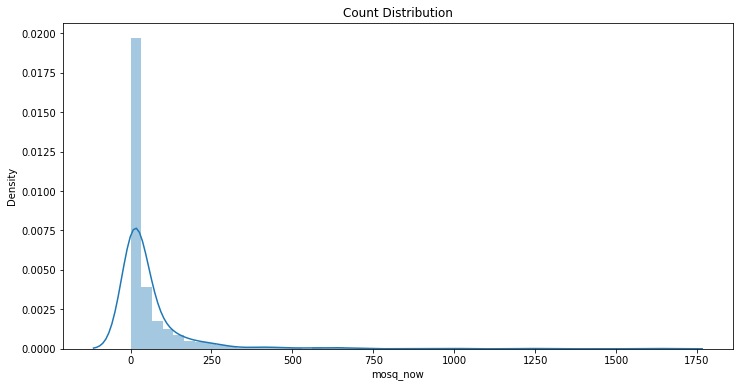

In [9]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [10]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.95)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

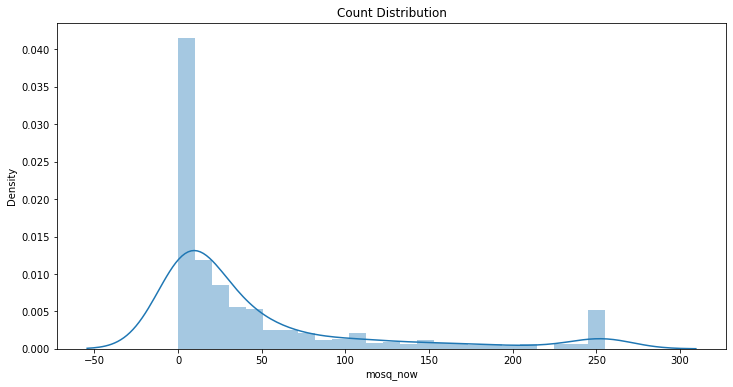

In [11]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

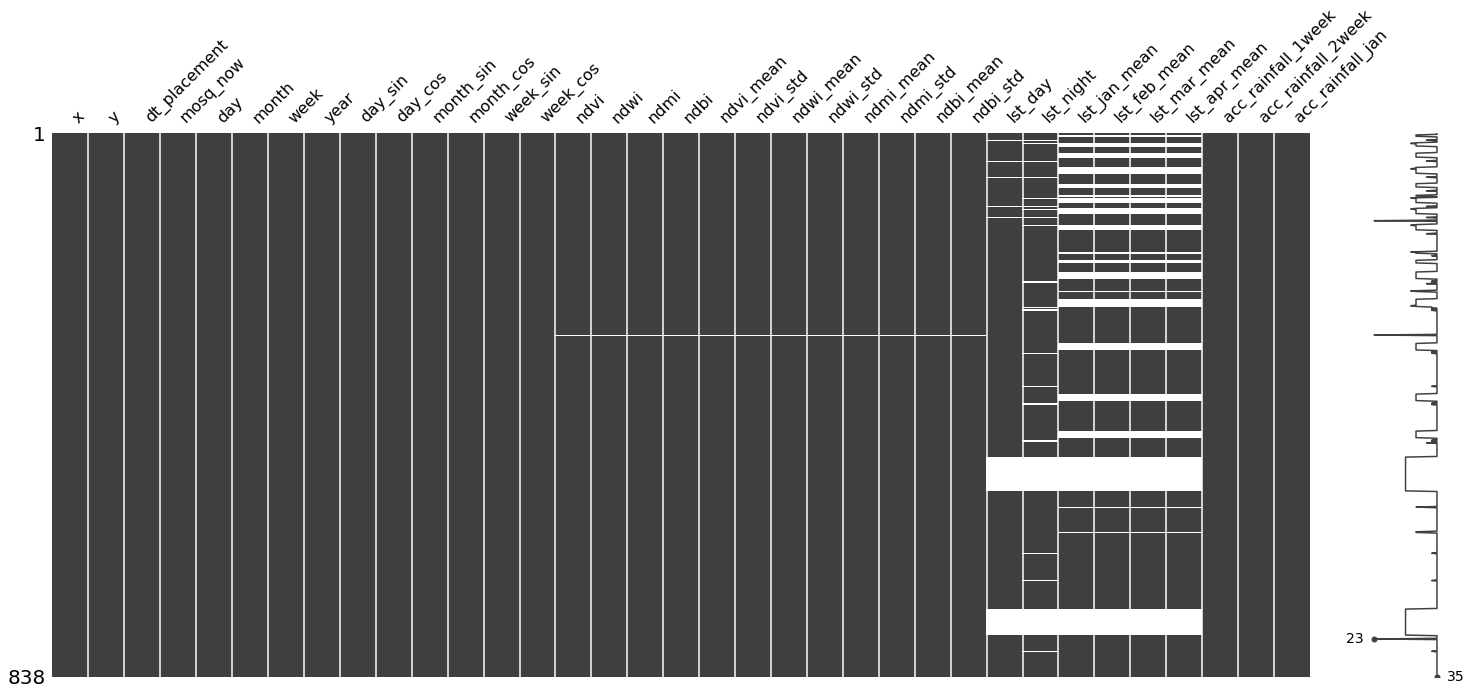

In [12]:
missingno.matrix(mosquito_data_nuts2)

In [13]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

# features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                         'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
#                         'lst_day', 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [14]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

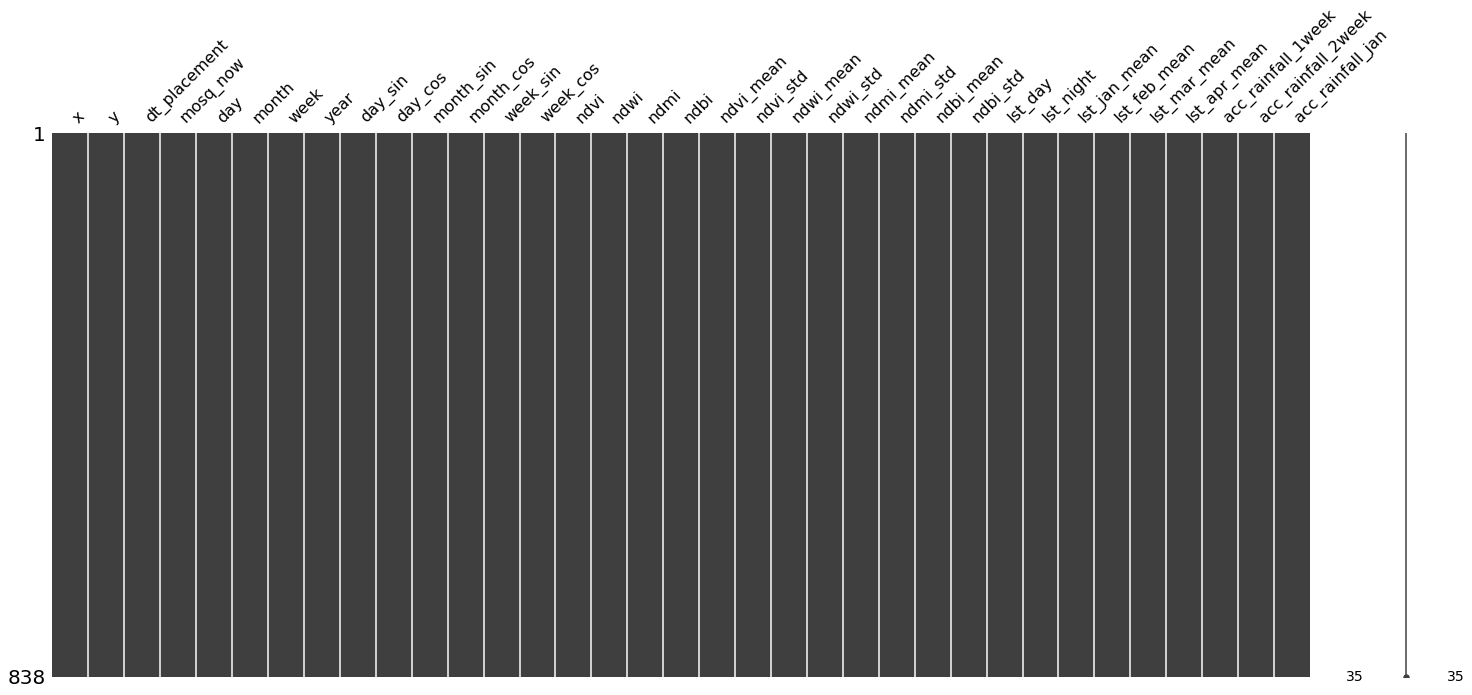

In [15]:
missingno.matrix(mosquito_data_nuts2)

In [16]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [17]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.    16.5  255.15]


In [18]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.37006 | Val Loss: 31.07980 | Train Acc: 4.247| Val Acc: 3.931
Epoch 002: | Train Loss: 37.01476 | Val Loss: 30.11151 | Train Acc: 3.574| Val Acc: 3.599
Epoch 003: | Train Loss: 35.38725 | Val Loss: 28.32128 | Train Acc: 3.224| Val Acc: 3.209
Epoch 004: | Train Loss: 34.65796 | Val Loss: 25.62308 | Train Acc: 3.030| Val Acc: 2.614
Epoch 005: | Train Loss: 34.15333 | Val Loss: 24.51717 | Train Acc: 2.939| Val Acc: 2.547
Epoch 006: | Train Loss: 33.81182 | Val Loss: 23.37563 | Train Acc: 2.878| Val Acc: 2.082
Epoch 007: | Train Loss: 33.56280 | Val Loss: 23.24399 | Train Acc: 2.833| Val Acc: 2.004
Epoch 008: | Train Loss: 33.37260 | Val Loss: 23.47905 | Train Acc: 2.812| Val Acc: 1.989
Epoch 009: | Train Loss: 32.90983 | Val Loss: 23.95063 | Train Acc: 2.750| Val Acc: 1.989
Epoch 010: | Train Loss: 32.90479 | Val Loss: 23.97583 | Train Acc: 2.764| Val Acc: 2.000
Epoch 011: | Train Loss: 32.66969 | Val Loss: 23.82156 | Train Acc: 2.653| Val Acc: 1.993
Epoch 012:

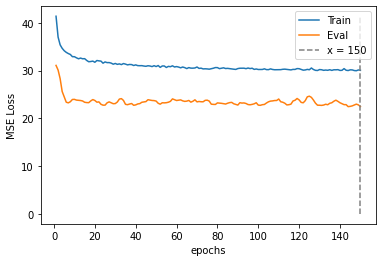

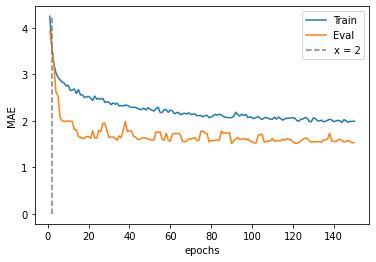

In [19]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [20]:
metrics(train, test, threshold=30)

MAE on train set:  31.079157946981983
min prediction: 1
max prediction: 201

MAE on test set:  29.326335817412918
Error ⩽ 30: 69.47 %
min prediction: 1
max prediction: 228


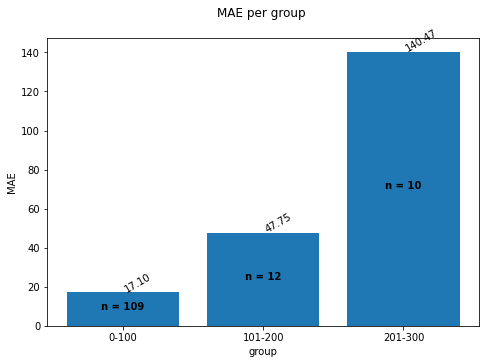

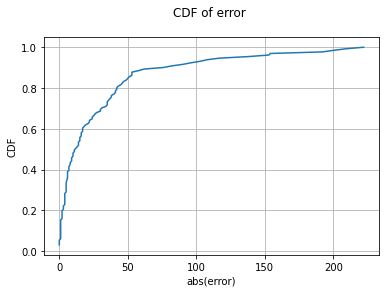

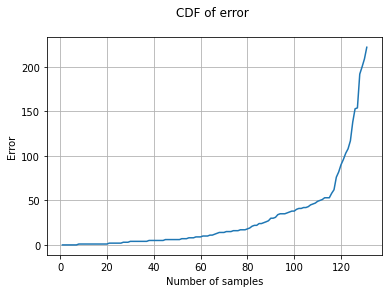

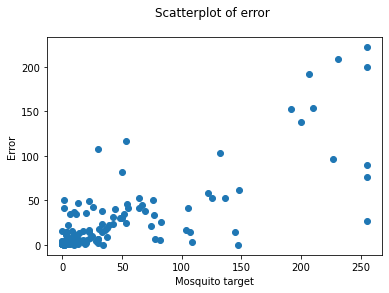

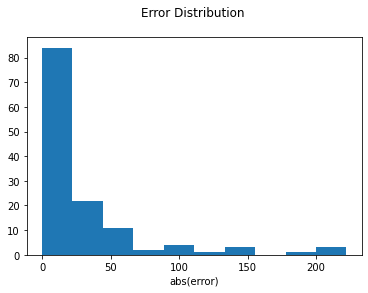

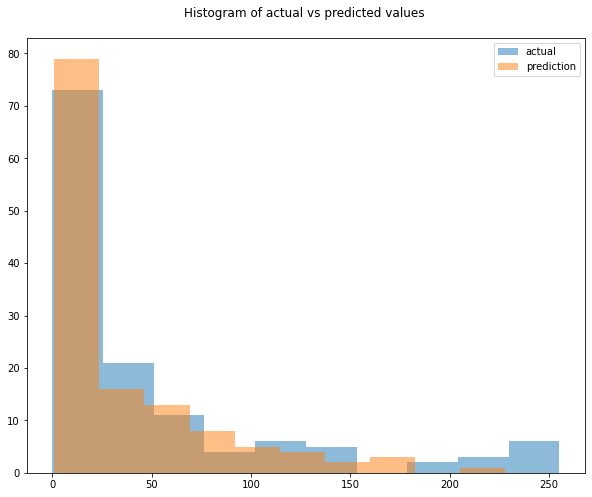

In [21]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.66558 | Val Loss: 0.00010 | Train Acc: 2.450| Val Acc: 0.458
Epoch 002: | Train Loss: 33.13856 | Val Loss: 0.19758 | Train Acc: 2.354| Val Acc: 0.542
Epoch 003: | Train Loss: 32.78941 | Val Loss: 0.59817 | Train Acc: 2.260| Val Acc: 0.542
Epoch 004: | Train Loss: 32.96069 | Val Loss: 0.42913 | Train Acc: 2.277| Val Acc: 0.542
Epoch 005: | Train Loss: 32.59471 | Val Loss: 0.17822 | Train Acc: 2.242| Val Acc: 0.542
Epoch 006: | Train Loss: 32.70112 | Val Loss: 0.00771 | Train Acc: 2.195| Val Acc: 0.542
Epoch 007: | Train Loss: 32.67875 | Val Loss: 0.03112 | Train Acc: 2.216| Val Acc: 0.542
Epoch 008: | Train Loss: 32.45843 | Val Loss: 0.24994 | Train Acc: 2.166| Val Acc: 0.542
Epoch 009: | Train Loss: 32.52364 | Val Loss: 0.28905 | Train Acc: 2.225| Val Acc: 0.542
Epoch 010: | Train Loss: 32.47745 | Val Loss: 0.08039 | Train Acc: 2.176| Val Acc: 0.542
Epoch 011: | Train Loss: 32.56701 | Val Loss: 0.01370 | Train Acc: 2.154| Val Acc: 0.542
Epoch 012: | Train Lo

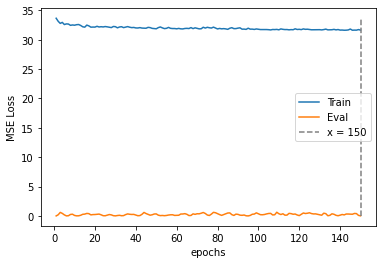

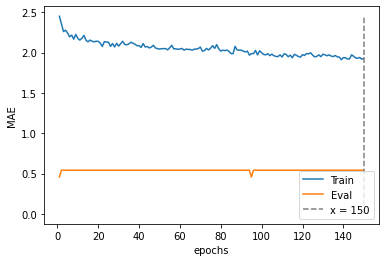

In [22]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [23]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'wb'))